# 03 · The problem zoo: twelve problems, each hard for its own reason

`experiments/problems/zoo.py` is a registry of regime-recovery problems, each
built to break **one** assumption: the law is not in the symbolic library;
the *gap* between laws is outside the library's span; there are 3 or 4
regimes; the law has two inputs; one law is a rescaled copy of the other;
the response has the same mean and variance under both laws. In every
problem all regimes share **one** input distribution, so only the equation
can tell them apart, and the noise is set so the closest pair sits at a
chosen separation $\rho$.

This notebook reads the committed results (`results/problems/`), re-runs
two problems live, and shows how to add your own.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

In [2]:
cat = pd.read_csv(RES / "problems" / "problems_catalog.csv")
cat[["problem", "K", "d", "truths", "in_library", "gap_outside_library", "why"]]

,problem,K,d,truths,in_library,gap_outside_library,why
0,frequency_shift,2,1,sin(x) | sin(1.3*x),False,2.9660e-06,"same shape, 30% faster: sin(1.3x) is not a lib..."
1,saturation,2,1,1 - exp(-x) | tanh(x),False,5.9185e-06,two saturating curves with the same slope at 0...
2,kink,2,1,"max(0, x) | max(0, x - 0.8)",False,1.6674e-03,"a hinge that moves; identical on x < 0, non-sm..."
3,interaction,2,2,x1*x2 | x1 + x2,True,4.0586e-31,two inputs; the regimes differ only in how the...
4,damping,2,1,sin(2*x) | sin(2*x)*exp(-0.3*x),False,8.7979e-05,an envelope; the gap is zero at x=0 and grows;...
5,power_exponent,2,1,x^1.5 | x^1.8,False,2.1430e-10,"two power laws, close exponents, both between ..."
6,three_way,3,1,x^2 | 0.5*x^3 | 2*sin(x),True,2.1515e-30,K = 3; cubic and 2 sin(x) nearly coincide on |...
7,four_way,4,1,x | x^2 - 1 | 1.5*sin(2*x) | 2*log1p(|x|) - 1,True,6.4399e-30,"K = 4, six pairs, the tightest one sets the noise"
8,rescaled_copy,2,1,x^2 + sin(x) | 0.7*(x^2 + sin(x)),True,1.9278e-31,"same shape, 70% amplitude: the gap is proporti..."
9,moment_matched,2,1,x | 0.9682*(x^2 - 1.333),True,1.6372e-30,y has the same mean and variance under both la...


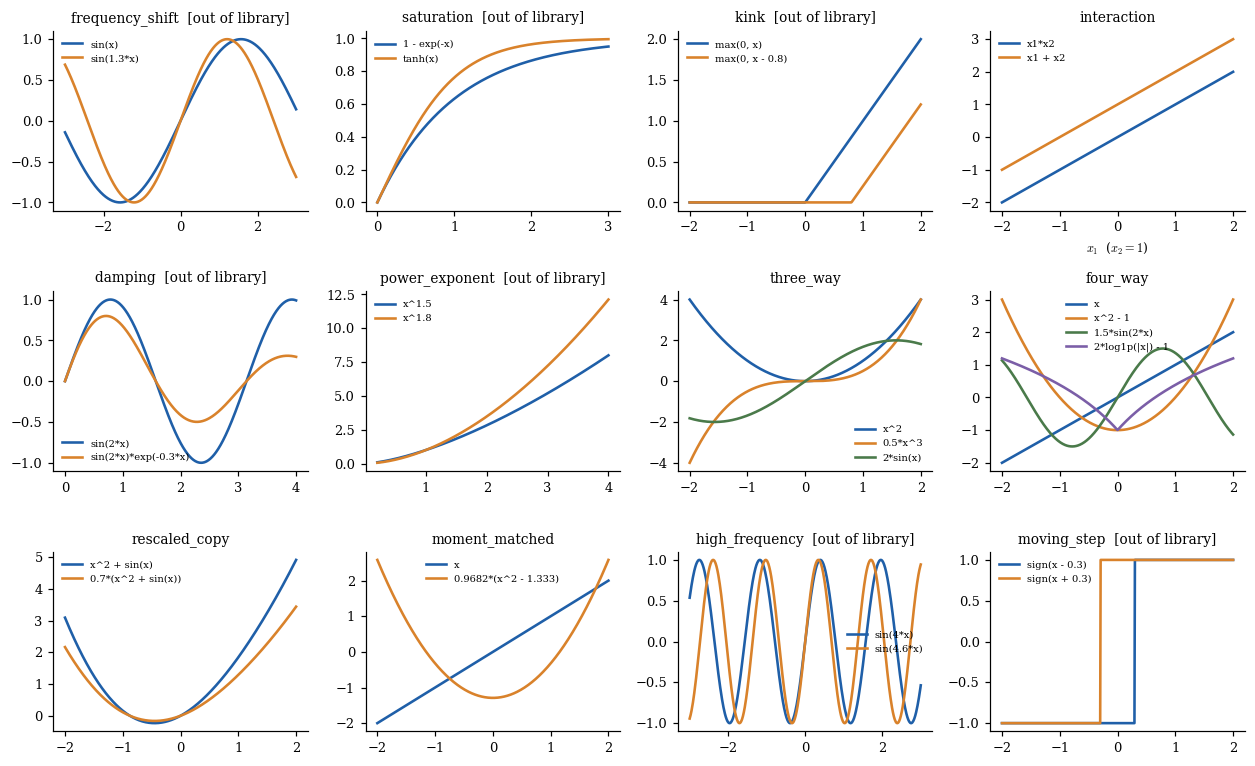

In [3]:
from analysis.figs_problems import FIGURES as PF
PF["problem_atlas"]();

## The results, against the oracle

The oracle knows the true laws and picks the one with the smaller residual:
the Bayes ceiling. `gap` columns are excess error over it, averaged over the
reporting seeds {11, 23, 42}.

In [4]:
S = pd.read_csv(RES / "problems" / "problems_summary.csv")
cols = ["oracle", "lrdsr", "soft_em", "mechanism_kmeans", "profile_kmeans", "geometry"]
S.pivot_table(index="problem", columns="rho", values=["lrdsr_gap", "soft_em_gap"]).round(3)

lrdsr_gap               soft_em_gap              
rho                  0.10   0.25   1.00        0.10   0.25   1.00
problem                                                          
damping             0.022 -0.000  0.000       0.056  0.011  0.000
four_way            0.016 -0.009  0.000       0.042 -0.002  0.000
frequency_shift     0.024  0.004  0.000       0.013  0.000  0.000
high_frequency      0.271  0.344  0.096       0.211  0.067  0.009
interaction         0.009 -0.002  0.000       0.000  0.016  0.000
kink                0.011  0.002  0.000       0.020 -0.002  0.000
moment_matched      0.002  0.013  0.000       0.018  0.009  0.000
moving_step         0.036  0.038  0.004       0.033  0.036  0.007
power_exponent      0.013 -0.002  0.000       0.027 -0.007  0.000
rescaled_copy       0.004 -0.009  0.002       0.033  0.004  0.000
saturation          0.007  0.009  0.000       0.020  0.002  0.000
three_way          -0.002  0.011  0.000       0.016  0.002  0.000

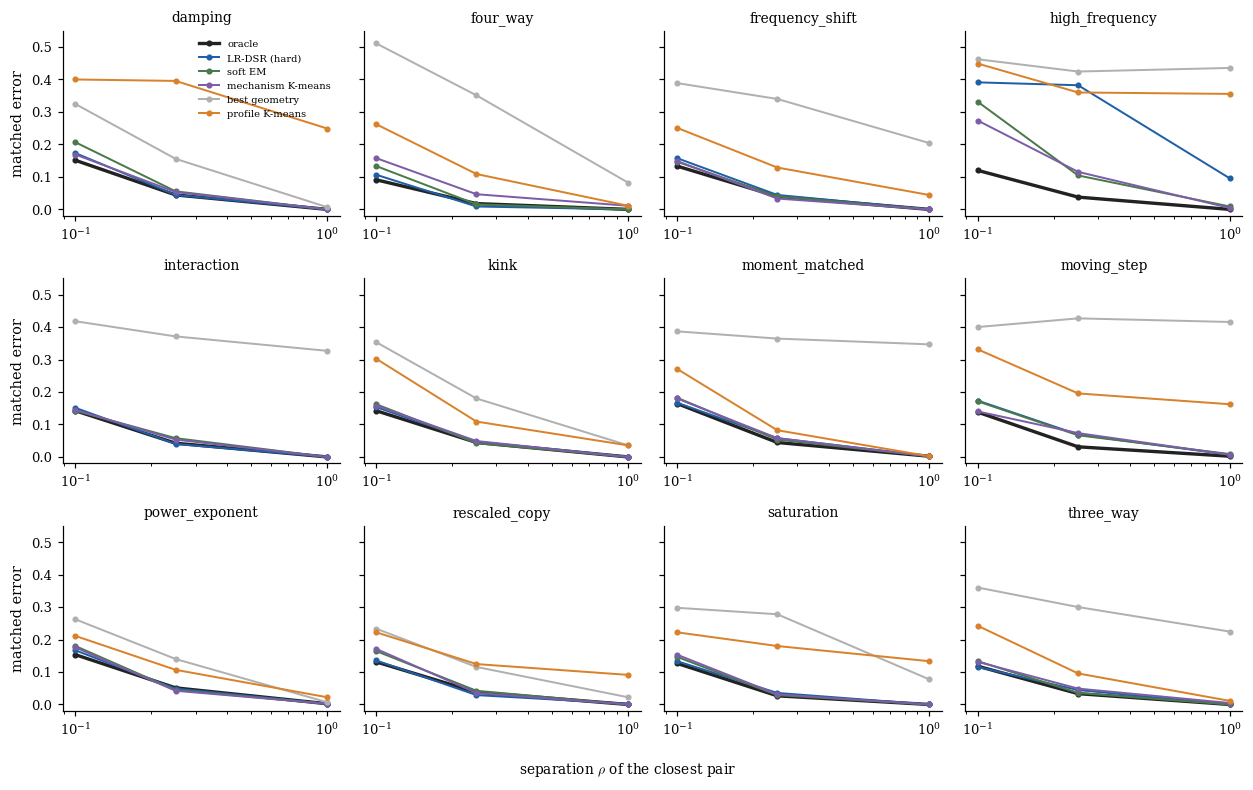

In [5]:
PF["problem_error_vs_rho"]();

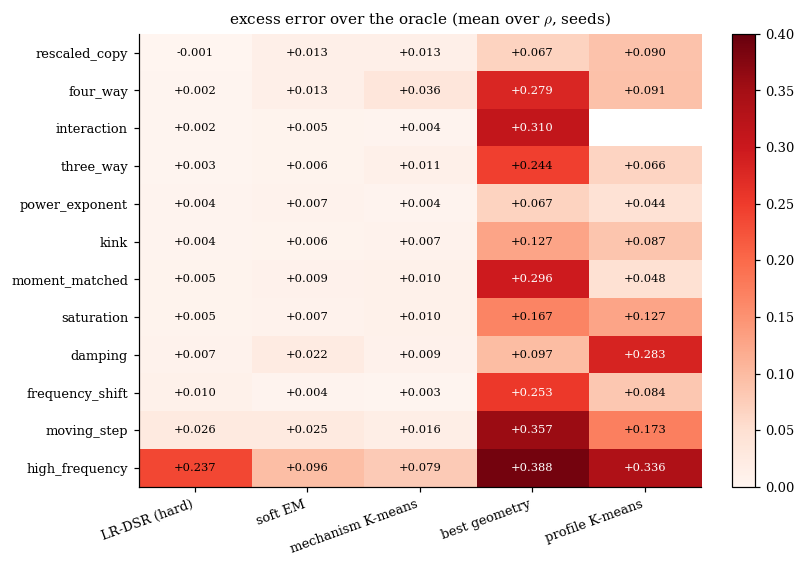

In [6]:
PF["problem_gap_heatmap"]();

## Why `high_frequency` fails and `frequency_shift` does not

Both pairs are "out of the library" — no `sin(1.3x)` or `sin(4.6x)` term
exists. What matters for **assignment** is whether the library can represent
the *gap* between the laws. `gap_outside_library` measures that share: tiny
for a 30% frequency shift, a third of the gap for $\sin 4x$ vs $\sin 4.6x$.
Run both live at $\rho = 0.25$:

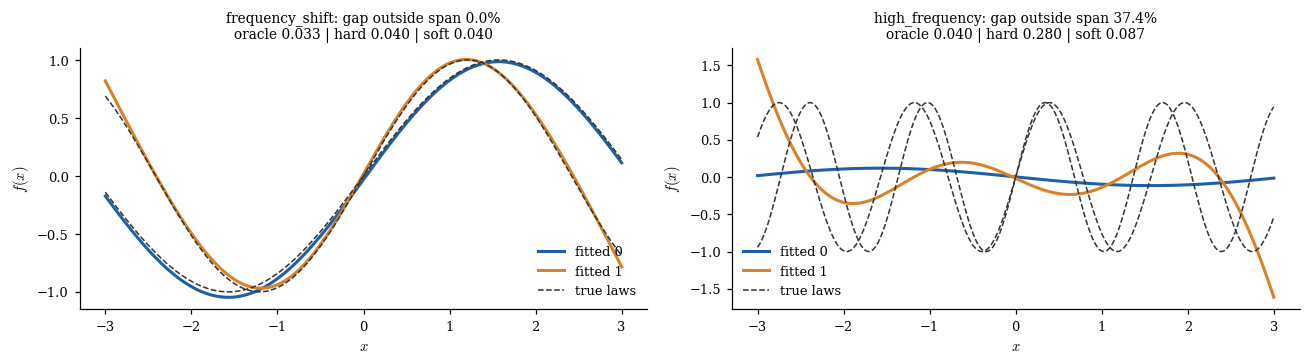

In [7]:
from experiments.problems.zoo import (PROBLEM_BY_NAME, gap_outside_library, make_windows,
                                      oracle_labels, sigma_for_rho)
from lrdsr import SoftLRDSR
from lrdsr.core.evaluation import aligned_accuracy
from experiments.common.fitting import fit_lrdsr, window_features

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for a, name in zip(ax, ("frequency_shift", "high_frequency")):
    P = PROBLEM_BY_NAME[name]
    X, y, z = make_windows(P, sigma_for_rho(P, 0.25), 150, 48, seed=11)
    Zf, fn = window_features(X, y)
    hard = fit_lrdsr(Zf, fn, X, y, P.feature_names, P.K, 11, alpha_geom=0.0)
    soft = SoftLRDSR(P.K, feature_names=P.feature_names, random_state=11).fit(X, y)
    def err(lab, z=z):
        return 1 - aligned_accuracy(z, lab)
    viz.plot_laws(hard.models, x_range=P.x_range, truth=[lambda x, f=f: f(x[:, None]) for f in P.laws], ax=a)
    a.set_title(f"{name}: gap outside span {gap_outside_library(P):.1%}\n"
                f"oracle {err(oracle_labels(P, X, y)):.3f} | hard {err(hard.labels):.3f} | "
                f"soft {err(soft.labels):.3f}", fontsize=9)
fig.tight_layout()

## Two inputs: the regimes differ only in how they combine

`interaction` is $x_1 x_2$ against $x_1 + x_2$ — same inputs, same ranges,
and the laws are recovered in their own symbols.

error: 0.033
   0.062965 +1.0957*x2 +1.4372*sin(x1)
   0.049691 +0.9607*(x1)*(x2)


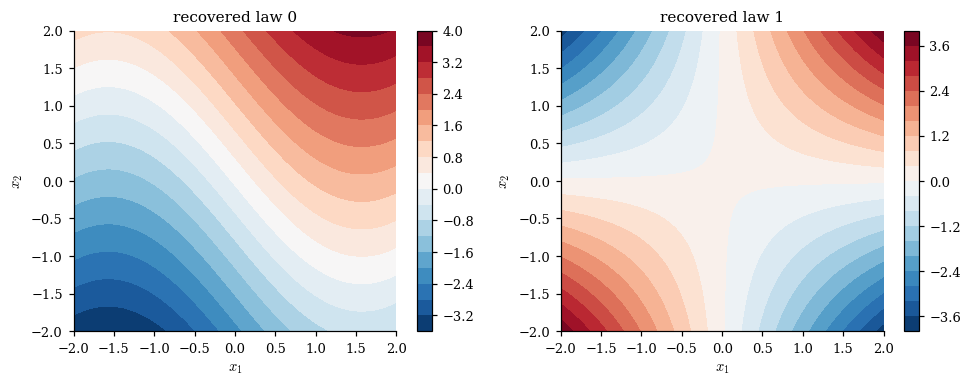

In [8]:
P = PROBLEM_BY_NAME["interaction"]
X, y, z = make_windows(P, sigma_for_rho(P, 0.25), 150, 48, seed=11)
Zf, fn = window_features(X, y)
hard = fit_lrdsr(Zf, fn, X, y, P.feature_names, P.K, 11, alpha_geom=0.0)
print("error:", round(1 - aligned_accuracy(z, hard.labels), 3))
for m in hard.models:
    print("  ", m.expression())
g = np.linspace(-2, 2, 60)
G1, G2 = np.meshgrid(g, g)
grid = np.column_stack([G1.ravel(), G2.ravel()])
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
for k, m in enumerate(hard.models):
    im = ax[k].contourf(G1, G2, m.predict(grid).reshape(G1.shape), 20, cmap="RdBu_r")
    ax[k].set(title=f"recovered law {k}", xlabel="$x_1$", ylabel="$x_2$")
    fig.colorbar(im, ax=ax[k])
fig.tight_layout()

## Add your own problem

A `Problem` is its laws, their names, a shared input sampler, and one line
saying why it is hard. `run_cell` runs every method on it.

In [9]:
from experiments.problems.zoo import Problem, _u
from experiments.problems.run import run_cell

mine = Problem(
    "my_pair",
    (lambda X: np.abs(X[..., 0]), lambda X: 0.5 * X[..., 0] ** 2 + 0.3),
    ("|x|", "0.5*x^2 + 0.3"), _u(-2.0, 2.0), 1, (-2.0, 2.0), False,
    "a V against a U: equal at two points, |x| is not a library term")
rows, laws = run_cell(mine, seed=11, rho_grid=(0.1, 0.5), n_windows=120, window_len=32)
pd.DataFrame(rows).pivot_table(index="method", columns="rho", values="matched_error").round(3)

rho,0.1,0.5
method,,
geometry,0.383,0.400
lrdsr,0.158,0.025
mechanism_kmeans,0.167,0.025
oracle,0.150,0.033
profile_kmeans,0.450,0.408
soft_em,0.300,0.017
